<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/22_zero_initialization_sigmoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.optimizers import Adam

from mlxtend.plotting import plot_decision_regions

In [20]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/DeepLearning/master/ushape.csv")

In [21]:
df=df.round(2)

In [22]:
df.head()

,X,Y,class
0,0.03,0.99,0.0
1,2.12,-0.05,1.0
2,0.88,-0.08,0.0
3,-0.06,-0.04,1.0
4,0.83,-0.54,1.0


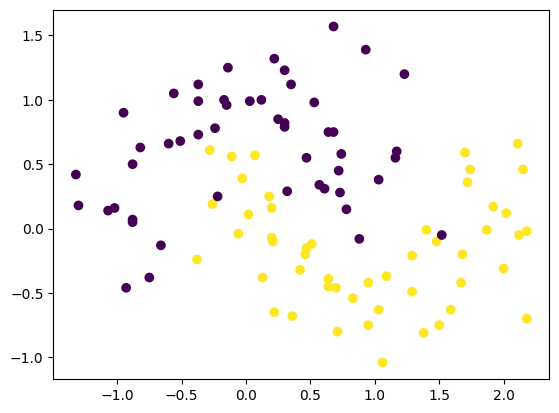

In [23]:
plt.scatter(df["X"],df["Y"],c=df["class"])

In [24]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [25]:
model=Sequential()
model.add(Dense(10,activation="sigmoid", input_dim=2))
model.add(Dense(1,activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.get_weights()

[array([[ 5.4480821e-01, -7.7113748e-02,  1.9350749e-01,  1.2885559e-01,
          6.7908078e-01,  3.5787410e-01,  3.1503493e-01,  6.3970333e-01,
         -5.1438808e-05,  3.4012586e-01],
        [ 3.4251577e-01,  6.9020778e-01,  7.0693821e-01,  2.0022970e-01,
         -5.0320113e-01, -6.1775577e-01,  1.4802039e-01, -4.3719718e-01,
         -1.4096230e-01, -1.7889786e-01]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2029283 ],
        [ 0.26413363],
        [-0.62728775],
        [ 0.58593076],
        [-0.439244  ],
        [ 0.35605234],
        [-0.45410654],
        [ 0.23190677],
        [-0.16899574],
        [-0.6178372 ]], dtype=float32),
 array([0.], dtype=float32)]

In [27]:
initial_weights = model.get_weights()

In [28]:
#initial_weights[0]=np.zeros(model.get_weights()[0].shape)*0.5
#initial_weights[1]=np.zeros(model.get_weights()[1].shape)*0.5
#initial_weights[2]=np.zeros(model.get_weights()[2].shape)*0.5
#initial_weights[3]=np.zeros(model.get_weights()[3].shape)*0.5

initial_weights[0]=np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1]=np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2]=np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3]=np.ones(model.get_weights()[3].shape)*0.5

In [29]:
model.set_weights(initial_weights)

In [30]:
initial_weights

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]]),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]]),
 array([0.5])]

In [31]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
history=model.fit(X,y,epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.5000 - loss: 2.0198 - val_accuracy: 0.5000 - val_loss: 1.8419
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 2.0056 - val_accuracy: 0.5000 - val_loss: 1.8296
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 1.9920 - val_accuracy: 0.5000 - val_loss: 1.8171
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 1.9779 - val_accuracy: 0.5000 - val_loss: 1.8047
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 1.9638 - val_accuracy: 0.5000 - val_loss: 1.7925
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 1.9510 - val_accuracy: 0.5000 - val_loss: 1.7802
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 1.9371 - val_accuracy: 0.5000 - val_loss: 1.7680
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 1.9239 - val_accuracy: 0.5000 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

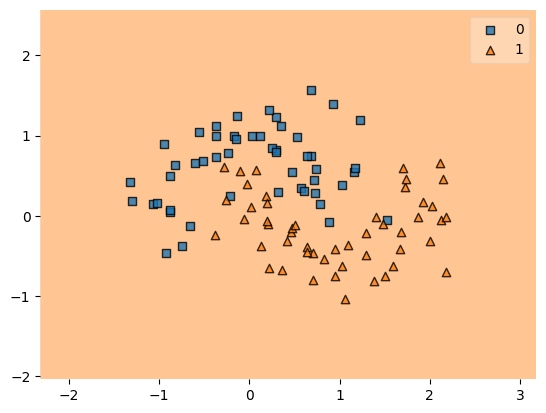

In [33]:
plot_decision_regions(X.values,y.values.astype('int'),model)

In [34]:
model.get_weights() # all set of weights are same if sigmoid with zero initial

[array([[0.43682918, 0.43682918, 0.43682918, 0.43682918, 0.43682918,
         0.43682918, 0.43682918, 0.43682918, 0.43682918, 0.43682918],
        [0.24640737, 0.24640737, 0.24640737, 0.24640737, 0.24640737,
         0.24640737, 0.24640737, 0.24640737, 0.24640737, 0.24640737]],
       dtype=float32),
 array([0.25624284, 0.25624284, 0.25624284, 0.25624284, 0.25624284,
        0.25624284, 0.25624284, 0.25624284, 0.25624284, 0.25624284],
       dtype=float32),
 array([[0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203],
        [0.23160203]], dtype=float32),
 array([0.22281691], dtype=float32)]